# YOLO Dataset Extractor — Droplets (matchTemplate)

Select a reference droplet in a frame -> the pipeline detects similar droplets in all frames and generates a **YOLO v5/v8** dataset ready for training.

**Output structure:**
```
dataset/
├── images/train/   (80%)
├── images/val/     (20%)
├── labels/train/
├── labels/val/
├── debug_preview/  <- check detections here
└── dataset.yaml
```

## 1. Dependency installation

In [26]:
import sys
!{sys.executable} -m pip install -r requirements.txt --quiet
print('Dependencies installed from requirements.txt')

Dependencies installed from requirements.txt


## 2. Imports

In [27]:
from pathlib import Path

from droplet_annotation.pipeline import (
    PipelineConfig,
    TemplateMatcher,
    dataset_summary,
    extract_candidates,
    make_cvat_zip,
    preview_frame,
    select_template,
    show_debug_samples,
    write_dataset,
)

## 3. Settings  

In [28]:
config = PipelineConfig(
    video_path="FF-I 20-100.avi",
    output_dir=f"dataset_{Path('FF-I 20-100.avi').stem}",
    class_name="droplet",
    val_split=0.2,
    frame_step=30,
    skip_empty=True,
    max_frames=0,
    template_frame=10,
    scale=2,
    threshold=0.75,
    nms_iou=0.3,
)

print("Settings loaded")
print(config)

Settings loaded
PipelineConfig(video_path='FF-I 20-100.avi', output_dir='dataset_FF-I 20-100', class_name='droplet', val_split=0.2, frame_step=30, skip_empty=True, max_frames=0, template_frame=10, scale=2, threshold=0.75, nms_iou=0.3, seed=42)


## 4. Template selection

Run this cell, draw a rectangle around **one droplet**, and press **ENTER**.

[INFO] Window opened at frame 10
       Draw a rectangle around ONE droplet and press ENTER.
Select a ROI and then press SPACE or ENTER button!
Cancel the selection process by pressing c button!


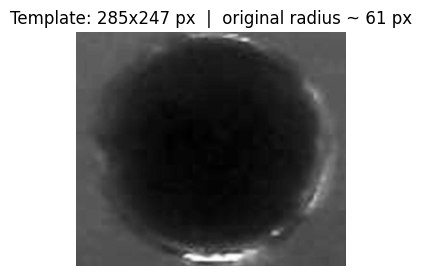

Template ready - original radius ~ 61 px


In [29]:
template, template_radius = select_template(
    video_path=config.video_path,
    template_frame=config.template_frame,
    scale=config.scale,
 )

matcher = TemplateMatcher(
    template=template,
    template_radius=template_radius,
    scale=config.scale,
    threshold=config.threshold,
    nms_iou=config.nms_iou,
 )

# Optional aliases for compatibility with previous cells
TEMPLATE = template
TEMPLATE_RADIUS = template_radius

## 5. Detection test on a single frame

Adjust `THRESHOLD` in cell 3 and run again if detections are poor.

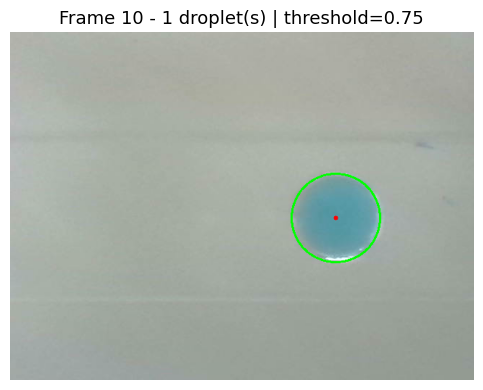

Detected droplets: 1


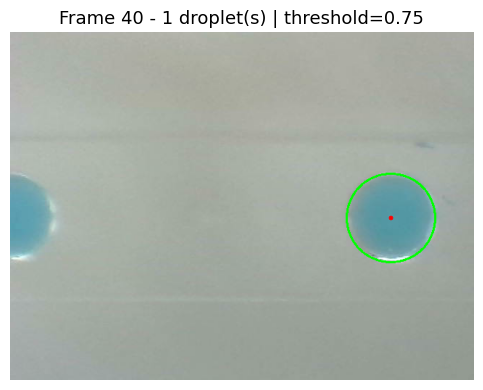

Detected droplets: 1


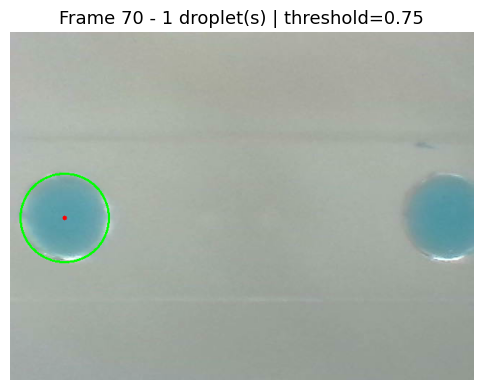

Detected droplets: 1


In [4]:
for frame_number in [config.template_frame, config.template_frame + 30, config.template_frame + 60]:
    preview_frame(config.video_path, frame_number, matcher)

## 6. Dataset extraction

In [10]:
state = extract_candidates(config, matcher)
out = state.out_dir

Video      : FF-I 20-100.avi
Frames     : 6780  |  FPS: 180.0
Resolution : 640x480
Step       : 30  ->  ~226 candidate frames




Extracted frames  : 222
Skipped frames    : 4  (no detections)
Total droplets    : 223


## 7. Train/val split and label writing

In [11]:
split_result = write_dataset(config, state)
print(split_result)

Split  ->  train: 178  |  val: 44
Debug: 10 samples at /home/julio/Droplet-Semi-Automatic-Annotation/dataset_FF-I 20-100/debug_preview
Dataset saved at: /home/julio/Droplet-Semi-Automatic-Annotation/dataset_FF-I 20-100
DatasetSplitResult(n_train=178, n_val=44, debug_samples=10)


## 8. Check samples from the generated dataset

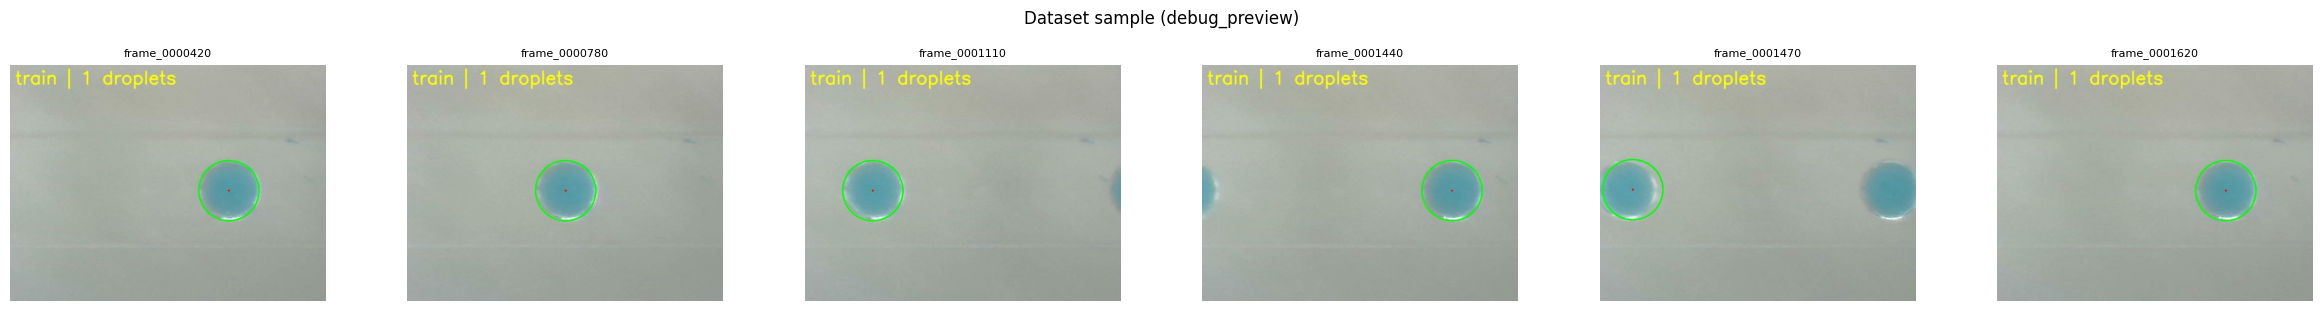

Total debug images: 19


In [12]:
show_debug_samples(out, max_samples=6)

## 9. Final summary and training command

In [13]:
print(dataset_summary(config, out))

  DATASET SUMMARY
  Class        : droplet
  Train        : 211 images
  Val          : 75 images
  Total        : 286 images
  Template     : frame 10  |  threshold=0.75
  dataset.yaml : /home/julio/Droplet-Semi-Automatic-Annotation/dataset_FF-I 20-100/dataset.yaml

To train with YOLOv8 (recommended):
  pip install ultralytics
  yolo train model=yolov8n.pt data=dataset_FF-I 20-100/dataset.yaml epochs=50 imgsz=640

To train with YOLOv5:
  python train.py --data dataset_FF-I 20-100/dataset.yaml --weights yolov5s.pt --epochs 50


## 10. Export annotations to CVAT (YOLO 1.1)

In [14]:
zip_train = out / "cvat_train.zip"
zip_val = out / "cvat_val.zip"

n_train_annotations = make_cvat_zip(out, "train", config.class_name, zip_train)
n_val_annotations = make_cvat_zip(out, "val", config.class_name, zip_val)

print(f"cvat_train.zip : {n_train_annotations} annotations -> obj_train_data/")
print(f"cvat_val.zip   : {n_val_annotations} annotations -> obj_valid_data/")

cvat_train.zip : 211 annotations -> obj_train_data/
cvat_val.zip   : 75 annotations -> obj_valid_data/
